# Bike Sharing Demand - Análisis Pre-ML

## Descripción del Dataset
Dataset de demanda de bicicletas compartidas en Washington D.C. (Capital Bikeshare program). Contiene registros horarios del sistema de alquiler de bicicletas entre 2011-2012, incluyendo condiciones climáticas y patrones temporales.

**Variables principales:**
- `datetime`: Fecha y hora del registro
- `season`: Estación del año (1=primavera, 2=verano, 3=otoño, 4=invierno)
- `holiday`: Si es día festivo (0=no, 1=sí)
- `workingday`: Si es día laboral (0=no, 1=sí)
- `weather`: Condición climática (1=despejado, 2=nublado, 3=lluvia ligera, 4=lluvia fuerte)
- `temp`: Temperatura en Celsius
- `atemp`: Sensación térmica en Celsius
- `humidity`: Humedad relativa (%)
- `windspeed`: Velocidad del viento
- `casual`: Número de usuarios casuales
- `registered`: Número de usuarios registrados
- `count`: Total de alquileres (casual + registered)

## Objetivo de Machine Learning
**Regresión**: Predecir la demanda total de bicicletas (`count`)

**Target**: `count` (número total de alquileres por hora)

**Features potenciales**:
- Temporales: hora del día, día de la semana, mes, año
- Climáticas: temperatura, sensación térmica, humedad, velocidad del viento, condición climática
- Categóricas: estación, día festivo, día laboral

## PASO 1: Cargar Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Cargar dataset
df = pd.read_csv('train.csv')

print("✅ Dataset cargado correctamente")

✅ Dataset cargado correctamente


## PASO 2: Ver Estructura del Dataset

In [2]:
df.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1


In [3]:
df.shape

(10886, 12)

In [4]:
df.dtypes.to_frame(name='dtype')

,dtype
datetime,str
season,int64
holiday,int64
workingday,int64
weather,int64
temp,float64
atemp,float64
humidity,int64
windspeed,float64
casual,int64


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    10886 non-null  str    
 1   season      10886 non-null  int64  
 2   holiday     10886 non-null  int64  
 3   workingday  10886 non-null  int64  
 4   weather     10886 non-null  int64  
 5   temp        10886 non-null  float64
 6   atemp       10886 non-null  float64
 7   humidity    10886 non-null  int64  
 8   windspeed   10886 non-null  float64
 9   casual      10886 non-null  int64  
 10  registered  10886 non-null  int64  
 11  count       10886 non-null  int64  
dtypes: float64(3), int64(8), str(1)
memory usage: 1020.7 KB


## PASO 3: Valores Faltantes

In [6]:
# Contar valores faltantes
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing_Count': missing,
    'Missing_Percentage': missing_pct
})

missing_df = missing_df[missing_df['Missing_Count'] > 0].sort_values('Missing_Count', ascending=False)

if len(missing_df) > 0:
    display(missing_df)
else:
    print("✅ No hay valores faltantes")

✅ No hay valores faltantes


## PASO 4: Gráfico del Target

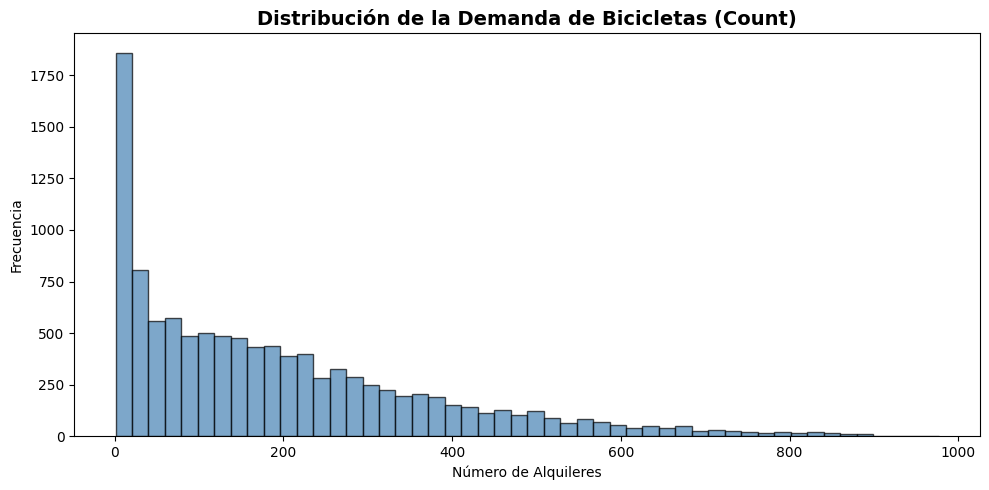


=== ESTADÍSTICAS DEL TARGET ===
count    10886.000000
mean       191.574132
std        181.144454
min          1.000000
25%         42.000000
50%        145.000000
75%        284.000000
max        977.000000
Name: count, dtype: float64


In [7]:
# Distribución del target
plt.figure(figsize=(10, 5))
plt.hist(df['count'], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
plt.title('Distribución de la Demanda de Bicicletas (Count)', fontsize=14, fontweight='bold')
plt.xlabel('Número de Alquileres')
plt.ylabel('Frecuencia')
plt.tight_layout()
plt.show()

print(f"\n=== ESTADÍSTICAS DEL TARGET ===")
print(df['count'].describe())

---
# LIMPIEZA DE DATOS

## Extracción de Features Temporales

In [8]:
# Convertir datetime a formato pandas
df['datetime'] = pd.to_datetime(df['datetime'])

# Extraer componentes temporales
df['year'] = df['datetime'].dt.year
df['month'] = df['datetime'].dt.month
df['day'] = df['datetime'].dt.day
df['hour'] = df['datetime'].dt.hour
df['dayofweek'] = df['datetime'].dt.dayofweek  # 0=Lunes, 6=Domingo

# Eliminar columna datetime original (ya no la necesitamos)
df = df.drop('datetime', axis=1)

print("✅ Features temporales extraídas")
print(f"\nNuevas columnas: {df.columns.tolist()}")
print(f"Shape: {df.shape}")

✅ Features temporales extraídas

Nuevas columnas: ['season', 'holiday', 'workingday', 'weather', 'temp', 'atemp', 'humidity', 'windspeed', 'casual', 'registered', 'count', 'year', 'month', 'day', 'hour', 'dayofweek']
Shape: (10886, 16)


## Tratamiento de Outliers

In [9]:
# Estadísticas de variables numéricas
df.describe()

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,year,month,day,hour,dayofweek
count,10886.000000,10886.000000,10886.000000,10886.000000,10886.00000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000
mean,2.506614,0.028569,0.680875,1.418427,20.23086,23.655084,61.886460,12.799395,36.021955,155.552177,191.574132,2011.501929,6.521495,9.992559,11.541613,3.013963
std,1.116174,0.166599,0.466159,0.633839,7.79159,8.474601,19.245033,8.164537,49.960477,151.039033,181.144454,0.500019,3.444373,5.476608,6.915838,2.004585
min,1.000000,0.000000,0.000000,1.000000,0.82000,0.760000,0.000000,0.000000,0.000000,0.000000,1.000000,2011.000000,1.000000,1.000000,0.000000,0.000000
25%,2.000000,0.000000,0.000000,1.000000,13.94000,16.665000,47.000000,7.001500,4.000000,36.000000,42.000000,2011.000000,4.000000,5.000000,6.000000,1.000000
50%,3.000000,0.000000,1.000000,1.000000,20.50000,24.240000,62.000000,12.998000,17.000000,118.000000,145.000000,2012.000000,7.000000,10.000000,12.000000,3.000000
75%,4.000000,0.000000,1.000000,2.000000,26.24000,31.060000,77.000000,16.997900,49.000000,222.000000,284.000000,2012.000000,10.000000,15.000000,18.000000,5.000000
max,4.000000,1.000000,1.000000,4.000000,41.00000,45.455000,100.000000,56.996900,367.000000,886.000000,977.000000,2012.000000,12.000000,19.000000,23.000000,6.000000


In [10]:
# Verificar si hay valores negativos o extremos
print("Valores negativos en count:", (df['count'] < 0).sum())
print("Valores negativos en temp:", (df['temp'] < 0).sum())
print("Valores negativos en humidity:", (df['humidity'] < 0).sum())
print("Valores negativos en windspeed:", (df['windspeed'] < 0).sum())

print("\n✅ No se detectan outliers problemáticos")

Valores negativos en count: 0
Valores negativos en temp: 0
Valores negativos en humidity: 0
Valores negativos en windspeed: 0

✅ No se detectan outliers problemáticos


---
# PREPROCESAMIENTO

## Separar Features y Target

In [11]:
# Eliminar columnas que NO son features (casual y registered son componentes del target)
features_to_drop = ['casual', 'registered', 'count']
X = df.drop(features_to_drop, axis=1).values
y = df['count'].values

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"\nNombre de features:")
print(df.drop(features_to_drop, axis=1).columns.tolist())

X shape: (10886, 13)
y shape: (10886,)

Nombre de features:
['season', 'holiday', 'workingday', 'weather', 'temp', 'atemp', 'humidity', 'windspeed', 'year', 'month', 'day', 'hour', 'dayofweek']


## Train-Test Split Manual (80-20)

In [12]:
# Configuración
np.random.seed(42)
test_size = 0.2

# Generar índices aleatorios
n_samples = len(X)
indices = np.random.permutation(n_samples)

# Calcular punto de corte
test_size_abs = int(n_samples * test_size)
train_size_abs = n_samples - test_size_abs

# Dividir índices
train_indices = indices[:train_size_abs]
test_indices = indices[train_size_abs:]

# Crear conjuntos
X_train = X[train_indices]
X_test = X[test_indices]
y_train = y[train_indices]
y_test = y[test_indices]

print(f"✅ Split completado")
print(f"Train: {X_train.shape[0]} muestras")
print(f"Test: {X_test.shape[0]} muestras")
print(f"\nDemanda promedio en Train: {y_train.mean():.1f}")
print(f"Demanda promedio en Test: {y_test.mean():.1f}")

✅ Split completado
Train: 8709 muestras
Test: 2177 muestras

Demanda promedio en Train: 191.8
Demanda promedio en Test: 190.8


## Escalado Manual (StandardScaler)

Fórmula: `x_scaled = (x - mean) / std`

**IMPORTANTE**: Calcular media y desviación estándar SOLO con datos de entrenamiento para evitar data leakage.

In [13]:
# Calcular media y desviación estándar del TRAIN set
mean_train = X_train.mean(axis=0)
std_train = X_train.std(axis=0)

# Evitar división por cero (columnas constantes)
std_train[std_train == 0] = 1

# Aplicar escalado
X_train_scaled = (X_train - mean_train) / std_train
X_test_scaled = (X_test - mean_train) / std_train  # Usar estadísticas del train

# Convertir a float explícitamente
X_train_scaled = X_train_scaled.astype(float)
X_test_scaled = X_test_scaled.astype(float)

print("✅ Escalado completado")
print(f"\nMedia de X_train_scaled (primeras 5 features): {X_train_scaled.mean(axis=0)[:5]}")
print(f"Desv. Std de X_train_scaled (primeras 5 features): {X_train_scaled.std(axis=0)[:5]}")

✅ Escalado completado

Media de X_train_scaled (primeras 5 features): [ 4.79579632e-17  3.02458968e-16  1.58967518e-15  1.45378153e-16
 -4.61283708e-15]
Desv. Std de X_train_scaled (primeras 5 features): [1. 1. 1. 1. 1.]


---
# VALIDACIÓN FINAL

## 1. Verificar Data Leakage

In [14]:
# Verificar que no hay índices compartidos entre train y test
shared_indices = np.intersect1d(train_indices, test_indices)

if len(shared_indices) == 0:
    print("✅ No hay data leakage (índices únicos en train y test)")
else:
    print(f"⚠️ ALERTA: {len(shared_indices)} índices compartidos detectados")

✅ No hay data leakage (índices únicos en train y test)


## 2. Verificar NaN e Infinitos

In [15]:
# Verificar NaN
nan_train = np.isnan(X_train_scaled).sum()
nan_test = np.isnan(X_test_scaled).sum()

# Verificar infinitos
inf_train = np.isinf(X_train_scaled).sum()
inf_test = np.isinf(X_test_scaled).sum()

print(f"NaN en X_train_scaled: {nan_train}")
print(f"NaN en X_test_scaled: {nan_test}")
print(f"Infinitos en X_train_scaled: {inf_train}")
print(f"Infinitos en X_test_scaled: {inf_test}")

if nan_train == 0 and nan_test == 0 and inf_train == 0 and inf_test == 0:
    print("\n✅ Datos limpios (sin NaN ni infinitos)")
else:
    print("\n⚠️ ALERTA: Hay NaN o infinitos en los datos")

NaN en X_train_scaled: 0
NaN en X_test_scaled: 0
Infinitos en X_train_scaled: 0
Infinitos en X_test_scaled: 0

✅ Datos limpios (sin NaN ni infinitos)


## 3. Comparar Distribuciones Train vs Test

In [16]:
# Comparar media y std de las primeras 5 features
print("=== COMPARACIÓN TRAIN vs TEST (primeras 5 features) ===")
print("\nMEDIA:")
print(f"Train: {X_train_scaled.mean(axis=0)[:5]}")
print(f"Test:  {X_test_scaled.mean(axis=0)[:5]}")

print("\nDESVIACIÓN ESTÁNDAR:")
print(f"Train: {X_train_scaled.std(axis=0)[:5]}")
print(f"Test:  {X_test_scaled.std(axis=0)[:5]}")

print("\n✅ Las distribuciones deberían ser similares (train estandarizado, test escalado con stats de train)")

=== COMPARACIÓN TRAIN vs TEST (primeras 5 features) ===

MEDIA:
Train: [ 4.79579632e-17  3.02458968e-16  1.58967518e-15  1.45378153e-16
 -4.61283708e-15]
Test:  [-0.0025217   0.04166151 -0.02624576 -0.01072373  0.00750649]

DESVIACIÓN ESTÁNDAR:
Train: [1. 1. 1. 1. 1.]
Test:  [1.00328424 1.11372562 1.00994884 0.96645964 0.98724238]

✅ Las distribuciones deberían ser similares (train estandarizado, test escalado con stats de train)


## Resumen Final

In [17]:
print("="*60)
print("RESUMEN DEL PREPROCESAMIENTO")
print("="*60)
print(f"Dataset original: {df.shape}")
print(f"Features después de ingeniería: {X.shape[1]}")
print(f"Train set: {X_train_scaled.shape}")
print(f"Test set: {X_test_scaled.shape}")
print(f"\nTarget (demanda de bicicletas):")
print(f"  - Mínimo: {y.min()}")
print(f"  - Promedio: {y.mean():.1f}")
print(f"  - Máximo: {y.max()}")
print(f"\n✅ Datos listos para entrenamiento de modelos de regresión")
print("="*60)

RESUMEN DEL PREPROCESAMIENTO
Dataset original: (10886, 16)
Features después de ingeniería: 13
Train set: (8709, 13)
Test set: (2177, 13)

Target (demanda de bicicletas):
  - Mínimo: 1
  - Promedio: 191.6
  - Máximo: 977

✅ Datos listos para entrenamiento de modelos de regresión
